# Sample-based Krylov Quantum Diagonalization (SKQD) with multiple reference systems

In [32]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

from qiskit import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler

from common.hamiltonians import build_antiferromagnetic_XX_Z_spin_1_2_chain_hamiltonian
from common.states import neel_state
from common.time_evolution_circuit import initial_circuit, build_krylov_measurement_circuits
from common.measurement_processing import extract_counts_sim, cumulative_counts, cumulative_counts_multiple_references
from common.sqd_energies import sqd_energies_from_cumulative

warnings.filterwarnings("ignore")

### 1. Map problem to quantum circuits and operators

In [33]:
# Define Hamiltonian
num_spins = 22
H_op = build_antiferromagnetic_XX_Z_spin_1_2_chain_hamiltonian(num_spins)

# Set parameters for quantum Krylov algorithm
krylov_dim = 10
dt = 0.15
num_trotter_steps = 6

In [34]:
# Prep `Neel` state as the reference state for evolution

qc_ref0 = neel_state(num_spins, shift=0)  # IBM baseline reference (Φ0)
qc_ref1 = neel_state(num_spins, shift=1)  # second reference (Φ1)

ref_preps_single = [qc_ref0]             # d=1 (IBM baseline)
ref_preps_multi  = [qc_ref0, qc_ref1]    # d=2 (multireference)


In [35]:
# Initialize time evolution circuits
qc_evol = initial_circuit(H_op, dt, num_trotter_steps, num_spins)

circuits_single, labels_single = build_krylov_measurement_circuits(
    ref_preps_single, krylov_dim, qc_evol
)
circuits_multi, labels_multi = build_krylov_measurement_circuits(
    ref_preps_multi, krylov_dim, qc_evol
)

print("single circuits:", len(circuits_single), "labels example:", labels_single[:3])
print("multi  circuits:", len(circuits_multi),  "labels example:", labels_multi[:3])

single circuits: 10 labels example: [(0, 0), (0, 1), (0, 2)]
multi  circuits: 20 labels example: [(0, 0), (0, 1), (0, 2)]


### 2. Optimize for target hardware

In [36]:
backend = AerSimulator(seed_simulator=12345)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

isa_single = pm.run(circuits=circuits_single)
isa_multi  = pm.run(circuits=circuits_multi)

### 3. Execute on target hardware

In [37]:
shots = 5_000
sampler = Sampler()

job_single = sampler.run(isa_single, shots=shots)
job_multi  = sampler.run(isa_multi,  shots=shots)

res_single = job_single.result()
res_multi  = job_multi.result()

In [38]:
counts_single_all = [extract_counts_sim(res_single, k) for k in range(krylov_dim)]
counts_multi_all  = [extract_counts_sim(res_multi,  k) for k in range(len(isa_multi))]

print("Example single counts keys:", list(counts_single_all[0].keys())[:3])
print("Example multi counts keys :", list(counts_multi_all[0].keys())[:3])

Example single counts keys: ['0101010101010101010101']
Example multi counts keys : ['0101010101010101010101']


### 4. Post-process results

In [39]:
# Get cumulative counts from the measurements

# IBM baseline cumulative (Φ0 only)
counts_single_cum = cumulative_counts(counts_single_all)

# multiple references
counts_multi_cum = cumulative_counts_multiple_references(labels_multi, counts_multi_all, krylov_dim, ref_preps_multi)
print("Built pooled multiref cumulative list length:", len(counts_multi_cum))

Built pooled multiref cumulative list length: 10


In [40]:
# num_ones = num_spins // 2
# scipy_kwargs = {"k": 2, "which": "SA"}

print("Single reference:")
ener_single = sqd_energies_from_cumulative(counts_single_cum, H_op, num_spins)

print("Multiple references:")
ener_multi  = sqd_energies_from_cumulative(counts_multi_cum,  H_op, num_spins)

Single reference:
[step 1] subspace N=1 -> E0=-22.000000
[step 2] subspace N=15 -> E0=-23.006659
[step 3] subspace N=25 -> E0=-23.456592
[step 4] subspace N=30 -> E0=-23.464006
[step 5] subspace N=43 -> E0=-23.484620
[step 6] subspace N=73 -> E0=-23.531205
[step 7] subspace N=118 -> E0=-23.610367
[step 8] subspace N=176 -> E0=-23.692742
[step 9] subspace N=226 -> E0=-23.758458
[step 10] subspace N=275 -> E0=-23.808273
Multiple references:
[step 1] subspace N=2 -> E0=-22.000000
[step 2] subspace N=32 -> E0=-23.181195
[step 3] subspace N=47 -> E0=-23.454012
[step 4] subspace N=53 -> E0=-23.456959
[step 5] subspace N=77 -> E0=-23.479405
[step 6] subspace N=132 -> E0=-23.519174
[step 7] subspace N=208 -> E0=-23.576780
[step 8] subspace N=304 -> E0=-23.668297
[step 9] subspace N=415 -> E0=-23.753560
[step 10] subspace N=507 -> E0=-23.804265


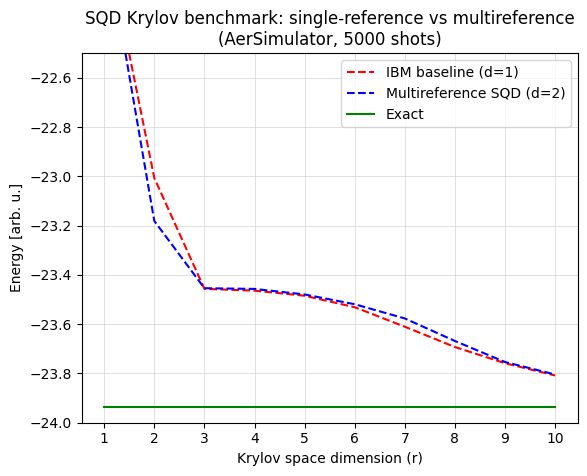

In [41]:
exact_gs_en = -23.934184
xs = np.arange(1, krylov_dim + 1)
plt.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5, alpha=1)
plt.plot(
    xs,
    ener_single,
    color="red",
    linestyle="--",
    label="IBM baseline (d=1)"
)
plt.plot(
    xs,
    ener_multi,
    color="blue",
    linestyle="--",
    label="Multireference SQD (d=2)"
)
plt.plot(
    xs,
    [exact_gs_en]*krylov_dim,
    color="green",
    linestyle="-",
    label="Exact"
)

plt.xticks(xs, xs)
plt.xlabel("Krylov space dimension (r)")
plt.ylabel("Energy [arb. u.]")
plt.title(f"SQD Krylov benchmark: single-reference vs multireference\n(AerSimulator, {shots} shots)")
plt.ylim([-24, -22.50])
plt.legend()
plt.show()